In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import random
random.seed(0)
%matplotlib inline

def load_data_from_file(fileName = "/content/drive/MyDrive/advertising.csv"):
  data = np.genfromtxt(fileName, dtype=None, delimiter=',', skip_header=1)
  features_X = data[:, :3]
  sales_Y = data[:, 3]

  intercept = np.ones((features_X.shape[0], 1))
  features_X = np.concatenate((intercept, features_X), axis=1)
  return features_X, sales_Y

In [24]:
#Question 2
features_X, _ = load_data_from_file()
print(features_X[:5,:])

[[  1.  230.1  37.8  69.2]
 [  1.   44.5  39.3  45.1]
 [  1.   17.2  45.9  69.3]
 [  1.  151.5  41.3  58.5]
 [  1.  180.8  10.8  58.4]]


In [25]:
#Question 3
_, sales_Y = load_data_from_file()
print(sales_Y.shape)

(200,)


In [26]:
def generate_random_value(bound = 10):
    return (random.random() - 0.5)*bound

def create_individual(n=4, bound=10):
    individual = [generate_random_value() for _ in range(n)]
    return individual

In [27]:
individual = create_individual()
print(individual)

[3.444218515250481, 2.5795440294030247, -0.79428419169155, -2.4108324970703663]


In [28]:
def compute_loss(individual):
    theta = np.array(individual)
    y_hat = features_X.dot(theta)
    loss  = np.multiply((y_hat-sales_Y), (y_hat-sales_Y)).mean()
    return loss

def compute_fitness(individual):
    loss = compute_loss(individual)
    fitness = 1/(loss+1)
    return fitness

In [29]:
#question 4
features_X, sales_Y = load_data_from_file()
individual = [4.09, 4.82, 3.10, 4.02]
fitness_score = compute_fitness(individual)
print(fitness_score)

1.0185991537088997e-06


In [30]:
def crossover(individual1, individual2, crossover_rate = 0.9):
    individual1_new = individual1.copy()
    individual2_new = individual2.copy()

    if crossover_rate >= 1.0:
        individual1_new = individual2.copy()
        individual2_new = individual1.copy()
    return individual1_new, individual2_new

In [31]:
#question 5
individual1 = [4.09, 4.82, 3.10, 4.02]
individual2 = [3.44, 2.57, -0.79, -2.41]

individual1, individual2 = crossover(individual1, individual2, 2.0)
print("individual1: ", individual1)
print("individual2: ", individual2)

individual1:  [3.44, 2.57, -0.79, -2.41]
individual2:  [4.09, 4.82, 3.1, 4.02]


In [64]:
def mutate(individual, mutation_rate = 0.05):
    individual_m = individual.copy()
    for i in range(len(individual_m)):
        if random.random() < mutation_rate:
            individual_m[i] += random.uniform(-1, 1)
    return individual_m

In [65]:
#Question 6
before_individual = [4.09, 4.82, 3.10, 4.02]
after_individual = mutate(individual, mutation_rate = 2.0)
print(before_individual == after_individual)

False


In [66]:
def initializePopulation(m):
  population = [create_individual() for _ in range(m)]
  return population

In [67]:
population = initializePopulation(100)
print(len(population))

100


In [68]:
def selection(sorted_old_population, m):
    index1 = random.randint(0, m-1)
    while True:
        index2 = random.randint(0, m-1)
        if (index2 != index1):
            break

    individual_s = sorted_old_population[index1]
    if index2 > index1:
        individual_s = sorted_old_population[index2]

    return individual_s

In [69]:
population = initializePopulation(m=100)
individual_s = selection(population, m = 100)
print(individual_s)

[0.9695725330725677, 3.927531851526634, -4.3114904449775455, -4.681622216644454]


In [70]:
def create_new_population(old_population, elitism=2, gen=1):
    m = len(old_population)
    sorted_population = sorted(old_population, key=compute_fitness)

    if gen%1 == 0:
        print("Best loss:", compute_loss(sorted_population[m-1]), "with chromsome: ", sorted_population[m-1])

    new_population = []
    while len(new_population) < m-elitism:
        # selection
        parent1 = selection(sorted_population, m)
        parent2 = selection(sorted_population, m)

        # crossover
        child1, child2 = crossover(parent1, parent2)

        # mutation

        child1 = mutate(child1)
        child2 = mutate(child2)

        new_population.append(child1)
        new_population.append(child2)
    for ind in sorted_population[m-elitism:]:
         new_population.append(ind)

    return new_population, compute_loss(sorted_population[m-1])

In [71]:
#Question 7
individual1 = [4.09, 4.82, 3.10, 4.02]
individual2 = [3.44, 2.57, -0.79, -2.41]
old_population = [individual1, individual2]
new_population, _ = create_new_population(old_population, elitism=2, gen=1)


Best loss: 123415.051528805 with chromsome:  [3.44, 2.57, -0.79, -2.41]


In [78]:
def run_GA():
    n_generations = 100
    m = 600
    features_X, sales_Y = load_data_from_file()
    population = initializePopulation(m)
    losses_list = []

    for i in range(n_generations):
        sorted_population = sorted(population, key=compute_fitness)

        best_loss = compute_loss(sorted_population[-1])
        losses_list.append(best_loss)

        new_population, _ = create_new_population(sorted_population, elitism=2, gen=i)

        population = new_population

    return losses_list


Best loss: 487.92763688533455 with chromsome:  [-1.350263157780065, -0.07378247079377953, -0.2853574733782942, 0.646552013712193]
Best loss: 487.92763688533455 with chromsome:  [-1.350263157780065, -0.07378247079377953, -0.2853574733782942, 0.646552013712193]
Best loss: 487.92763688533455 with chromsome:  [-1.350263157780065, -0.07378247079377953, -0.2853574733782942, 0.646552013712193]
Best loss: 487.92763688533455 with chromsome:  [-1.350263157780065, -0.07378247079377953, -0.2853574733782942, 0.646552013712193]
Best loss: 341.6205222393943 with chromsome:  [-1.350263157780065, -0.07378247079377953, 0.3253375474026483, 0.646552013712193]
Best loss: 334.2292603981594 with chromsome:  [-1.350263157780065, -0.07378247079377953, 0.06731389898499374, 0.646552013712193]
Best loss: 267.878270828495 with chromsome:  [-4.864555441432426, 0.1325704093042388, -0.3280961488884415, 0.5614993374019379]
Best loss: 267.878270828495 with chromsome:  [-4.864555441432426, 0.1325704093042388, -0.3280961

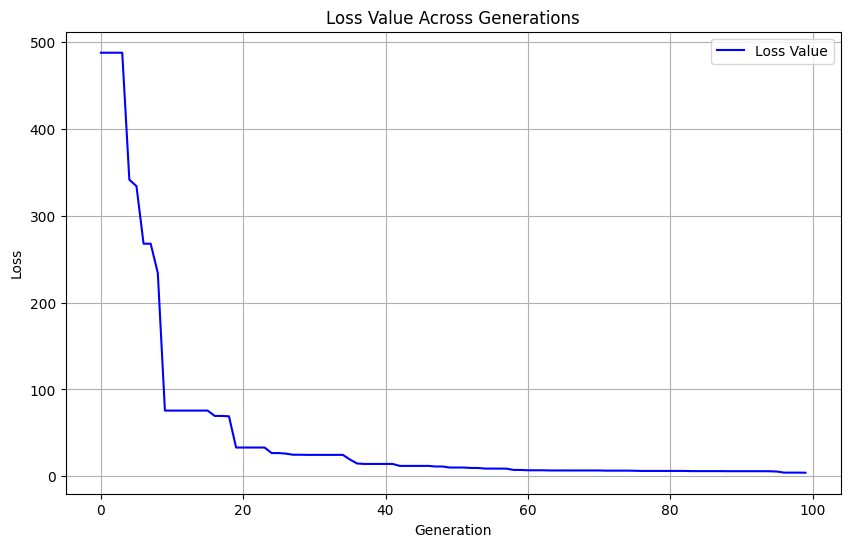

In [80]:
import matplotlib.pyplot as plt

def visualize_loss(losses_list):
    plt.figure(figsize=(10, 6))
    plt.plot(losses_list, color='blue', label='Loss Value')
    plt.title('Loss Value Across Generations')
    plt.xlabel('Generation')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

losses_list = run_GA()
visualize_loss(losses_list)

[-4.050156690846544, -0.1732787269675553, 2.205603681169129, -0.3317390470800108]


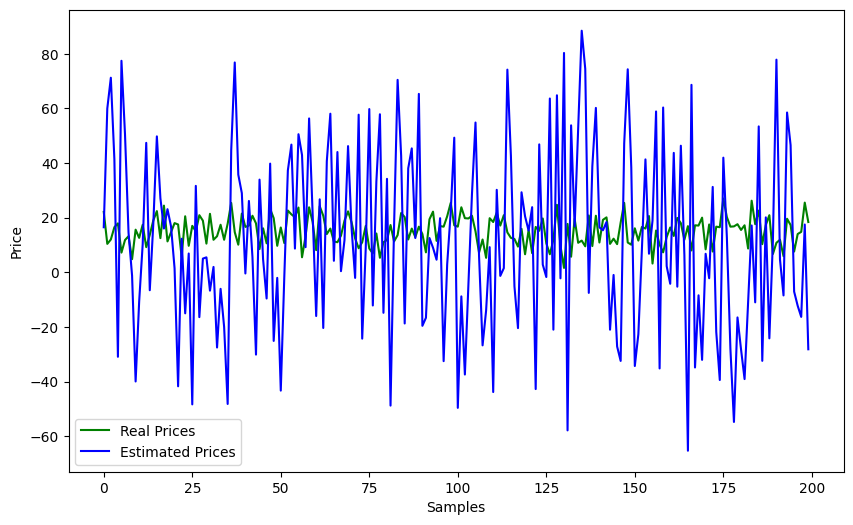

In [81]:
def visualize_predict_gt():
    sorted_population = sorted(population, key=compute_fitness)
    print(sorted_population[-1])  # In ra cá thể tốt nhất
    theta = np.array(sorted_population[-1])
    estimated_prices = []

    # Dự đoán giá trị dựa trên theta và features_X
    for feature in features_X:
        estimated_price = feature.dot(theta)
        estimated_prices.append(estimated_price)

    # Vẽ biểu đồ
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.xlabel('Samples')
    plt.ylabel('Price')
    plt.plot(sales_Y, c='green', label='Real Prices')
    plt.plot(estimated_prices, c='blue', label='Estimated Prices')
    plt.legend()
    plt.show()

# Gọi hàm visualize_predict_gt() để trực quan hóa
visualize_predict_gt()
